# Analyse des biais dans les offres d'emploi 👩‍💼⚖️

Projet Colab avec données imaginées.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib joblib -q

In [1]:
import random
import pandas as pd

random.seed(42)

masculine_words = ["agressif", "dominant", "compétitif", "rockstar", "ninja", "guerrier", "fonceur", "leader né", "impitoyable", "sous pression extrême"]
exclusionary_phrases = ["jeune diplômé", "sans contraintes familiales", "disponible en tout temps", "culture très masculine", "heures illimitées", "pas de télétravail possible", "présence obligatoire soir et weekend"]
inclusive_phrases = ["candidatures de tous horizons", "environnement inclusif", "horaire flexible", "équilibre travail vie personnelle", "accommodements raisonnables", "nous encourageons les femmes à postuler"]

def rule_score(text):
    lower = text.lower()
    m = [w for w in masculine_words if w in lower]
    e = [w for w in exclusionary_phrases if w in lower]
    i = [w for w in inclusive_phrases if w in lower]
    score = max(0, len(m)*2 + len(e)*3 - len(i)*2)
    risk = "élevé" if score >= 9 else "modéré" if score >= 4 else "faible"
    return score, risk, m, e, i

neutral_openings = [
    "Nous recrutons une personne pour rejoindre notre équipe.",
    "Notre organisation cherche une candidate ou un candidat motivé.",
    "Nous recherchons un profil capable de collaborer avec plusieurs équipes.",
]
biased_openings = [
    "Nous cherchons un rockstar developer agressif et ultra compétitif.",
    "Nous voulons un guerrier capable de dominer le marché.",
    "Poste pour fonceur impitoyable capable de travailler sous pression extrême.",
]
neutral_requirements = [
    "Expérience pertinente en gestion de projet.",
    "Capacité à communiquer clairement.",
    "Intérêt pour la collaboration.",
]
biased_requirements = [
    "Doit être jeune diplômé et sans contraintes familiales.",
    "Présence obligatoire soir et weekend.",
    "Heures illimitées attendues.",
    "Culture très masculine et compétitive.",
]
inclusive_sentences = [
    "Nous encourageons les femmes à postuler.",
    "Nous valorisons les candidatures de tous horizons.",
    "Notre environnement inclusif soutient la diversité.",
    "Un horaire flexible est possible.",
]

def make_posting(level):
    if level == "faible":
        parts = [random.choice(neutral_openings), random.choice(neutral_requirements), random.choice(inclusive_sentences), random.choice(inclusive_sentences)]
    elif level == "modéré":
        parts = [random.choice(neutral_openings), random.choice(neutral_requirements), random.choice(biased_requirements), random.choice(inclusive_sentences)]
    else:
        parts = [random.choice(biased_openings), random.choice(biased_requirements), random.choice(biased_requirements), "La personne devra être disponible en tout temps."]
    return " ".join(parts)

rows = []
for _ in range(600):
    level = random.choices(["faible", "modéré", "élevé"], weights=[.4, .35, .25])[0]
    text = make_posting(level)
    score, risk, m, e, i = rule_score(text)
    rows.append({"job_posting_text": text, "rule_bias_score": score, "bias_risk": risk, "masculine_terms": ", ".join(m), "exclusionary_terms": ", ".join(e), "inclusive_terms": ", ".join(i)})

df = pd.DataFrame(rows)
df.head()


,job_posting_text,rule_bias_score,bias_risk,masculine_terms,exclusionary_terms,inclusive_terms
0,Nous recrutons une personne pour rejoindre not...,1,faible,,heures illimitées,candidatures de tous horizons
1,Nous recherchons un profil capable de collabor...,0,faible,,,"horaire flexible, nous encourageons les femmes..."
2,Nous recrutons une personne pour rejoindre not...,0,faible,,,"candidatures de tous horizons, nous encourageo..."
3,Nous recherchons un profil capable de collabor...,1,faible,,culture très masculine,candidatures de tous horizons
4,Notre organisation cherche une candidate ou un...,1,faible,,présence obligatoire soir et weekend,horaire flexible


<Axes: title={'center': 'Distribution du risque de biais'}, xlabel='bias_risk'>

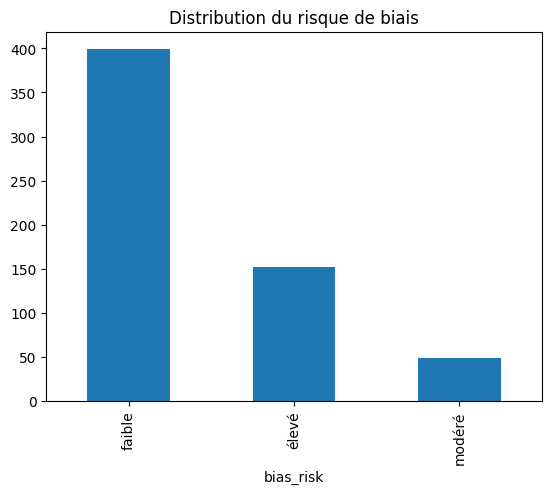

In [2]:
df['bias_risk'].value_counts().plot(kind='bar', title='Distribution du risque de biais')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df["job_posting_text"]
y = df["bias_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.98
              precision    recall  f1-score   support

      faible       1.00      1.00      1.00       100
      modéré       1.00      0.75      0.86        12
       élevé       0.93      1.00      0.96        38

    accuracy                           0.98       150
   macro avg       0.98      0.92      0.94       150
weighted avg       0.98      0.98      0.98       150



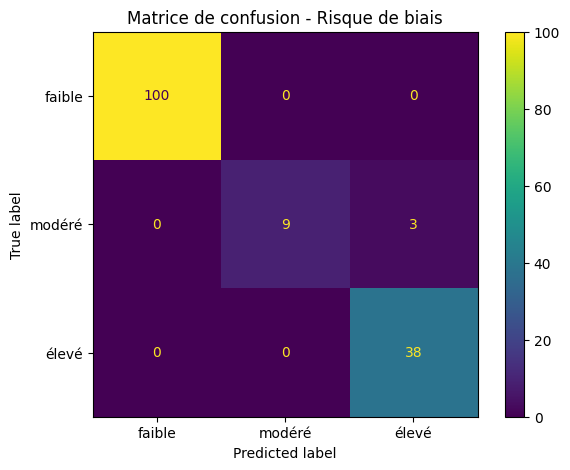

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
plt.title("Matrice de confusion - Risque de biais")
plt.show()

In [6]:
replacements = {
    "rockstar": "spécialiste expérimenté(e)",
    "ninja": "spécialiste",
    "guerrier": "personne engagée",
    "agressif": "proactif",
    "dominant": "capable de coordonner",
    "impitoyable": "rigoureux",
    "sous pression extrême": "dans un environnement dynamique",
    "disponible en tout temps": "avec disponibilité raisonnable",
    "heures illimitées": "horaire clair et soutenable",
}

def suggestions(text):
    lower = text.lower()
    tips = []
    for bad, better in replacements.items():
        if bad in lower:
            tips.append(f"Remplacer « {bad} » par « {better} ».")
    if "inclusif" not in lower and "candidatures de tous horizons" not in lower:
        tips.append("Ajouter une phrase encourageant les candidatures de tous horizons.")
    return tips or ["Le texte semble relativement inclusif selon ces règles simples."]

sample = "Nous cherchons un rockstar developer agressif et dominant, disponible en tout temps, capable de travailler sous pression extrême."

score, risk, m, e, i = rule_score(sample)
print("Texte:", sample)
print("Prédiction ML:", model.predict([sample])[0])
print("Score règles:", score)
print("Risque règles:", risk)
print("Mots détectés:", m + e)
print("\\nSuggestions:")
for tip in suggestions(sample):
    print("-", tip)


Texte: Nous cherchons un rockstar developer agressif et dominant, disponible en tout temps, capable de travailler sous pression extrême.
Prédiction ML: élevé
Score règles: 11
Risque règles: élevé
Mots détectés: ['agressif', 'dominant', 'rockstar', 'sous pression extrême', 'disponible en tout temps']
\nSuggestions:
- Remplacer « rockstar » par « spécialiste expérimenté(e) ».
- Remplacer « agressif » par « proactif ».
- Remplacer « dominant » par « capable de coordonner ».
- Remplacer « sous pression extrême » par « dans un environnement dynamique ».
- Remplacer « disponible en tout temps » par « avec disponibilité raisonnable ».
- Ajouter une phrase encourageant les candidatures de tous horizons.
